# Telefon Fiyat Segmenti Sınıflandırma Modeli

In [39]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

X_train_full = train_df.drop(columns=['price_range'])
y_train_full = train_df['price_range']

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full)

X_test_final = test_df.drop(columns=['id']).copy()

print("✅ Telefon Veri Seti Hazır!")
print(f"Eğitim Seti Özellik Sayısı: {X_train.shape[1]} | Satır Sayısı: {X_train.shape[0]}")
print(f"Doğrulama Seti Özellik Sayısı: {X_val.shape[1]} | Satır Sayısı: {X_val.shape[0]}")
print(f"Nihai Test Seti Özellik Sayısı: {X_test_final.shape[1]} | Satır Sayısı: {X_test_final.shape[0]}")

train_df.info()
train_df.tail()

✅ Telefon Veri Seti Hazır!
Eğitim Seti Özellik Sayısı: 20 | Satır Sayısı: 1600
Doğrulama Seti Özellik Sayısı: 20 | Satır Sayısı: 400
Nihai Test Seti Özellik Sayısı: 20 | Satır Sayısı: 1000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [40]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_val)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

print("==================================================================")
print("🌲 MODEL 1: DECISION TREE - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)")
print("==================================================================")
print(classification_report(y_val, dt_preds, target_names=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)']))

print("\n==================================================================")
print("🦁 MODEL 2: RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)")
print("==================================================================")
print(classification_report(y_val, rf_preds, target_names=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)']))

🌲 MODEL 1: DECISION TREE - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)
                precision    recall  f1-score   support

      Ucuz (0)       0.94      0.89      0.91       100
      Orta (1)       0.75      0.82      0.78       100
    Pahalı (2)       0.74      0.75      0.75       100
Çok Pahalı (3)       0.91      0.86      0.89       100

      accuracy                           0.83       400
     macro avg       0.83      0.83      0.83       400
  weighted avg       0.83      0.83      0.83       400


🦁 MODEL 2: RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)
                precision    recall  f1-score   support

      Ucuz (0)       0.94      0.96      0.95       100
      Orta (1)       0.82      0.82      0.82       100
    Pahalı (2)       0.82      0.79      0.81       100
Çok Pahalı (3)       0.93      0.95      0.94       100

      accuracy                           0.88       400
     macro avg       0.88      0.88      0.88       400
  weig

In [41]:
from sklearn.model_selection import cross_val_score

print("🔄 --- 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA) SONUÇLARI ---")
print("-" * 60)

dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"🌲 Decision Tree 5 Tur Skorları : {dt_cv_scores}")
print(f"🌲 Decision Tree ORTALAMA Başarı: %{dt_cv_scores.mean()*100:.2f}")
print("-" * 60)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"🦁 Random Forest 5 Tur Skorları : {rf_cv_scores}")
print(f"🦁 Random Forest ORTALAMA Başarı: %{rf_cv_scores.mean()*100:.2f}")

🔄 --- 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA) SONUÇLARI ---
------------------------------------------------------------
🌲 Decision Tree 5 Tur Skorları : [0.815625 0.815625 0.81875  0.784375 0.815625]
🌲 Decision Tree ORTALAMA Başarı: %81.00
------------------------------------------------------------
🦁 Random Forest 5 Tur Skorları : [0.86875  0.871875 0.86875  0.83125  0.846875]
🦁 Random Forest ORTALAMA Başarı: %85.75


## Random Forest Hiperparametre Optimizasyonu (n_estimators ve max_depth)

`GridSearchCV` kullanarak `n_estimators` ve `max_depth` için en iyi kombinasyonu bulalım.

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 8, 10, 12, None]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("En iyi parametreler:", grid_search.best_params_)
print("En iyi doğruluk skoru:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
En iyi parametreler: {'max_depth': 8, 'n_estimators': 200}
En iyi doğruluk skoru: 0.8706250000000001


### En iyi parametrelerle yeniden eğitilen modelin performans raporu

In [43]:
best_rf_model = grid_search.best_estimator_
best_rf_preds = best_rf_model.predict(X_val)

print("==================================================================")
print("🦁 OPTİMİZE EDİLMİŞ RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)")
print("==================================================================")
print(classification_report(y_val, best_rf_preds, target_names=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)']))

🦁 OPTİMİZE EDİLMİŞ RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)
                precision    recall  f1-score   support

      Ucuz (0)       0.92      0.96      0.94       100
      Orta (1)       0.80      0.79      0.79       100
    Pahalı (2)       0.82      0.79      0.81       100
Çok Pahalı (3)       0.95      0.96      0.96       100

      accuracy                           0.88       400
     macro avg       0.87      0.88      0.87       400
  weighted avg       0.87      0.88      0.87       400



### Optimize Edilmiş Random Forest Modeli İçin Karmaşıklık Matrisi (Confusion Matrix)

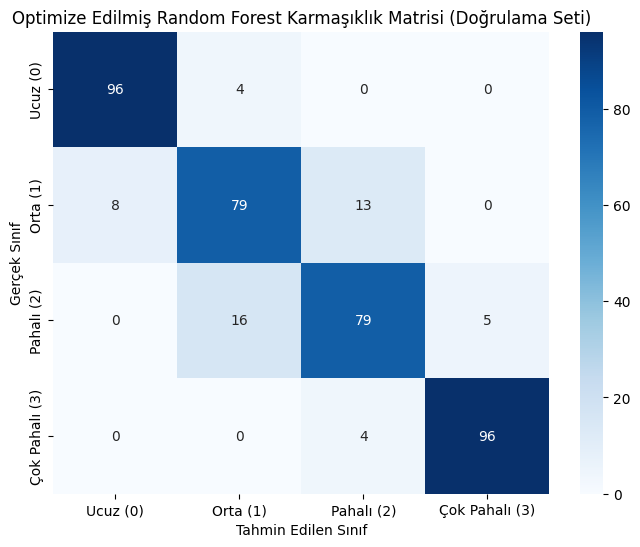

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, best_rf_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'],
            yticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'])
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Optimize Edilmiş Random Forest Karmaşıklık Matrisi (Doğrulama Seti)')
plt.show()

### Karar Ağacı Modeli İçin Karmaşıklık Matrisi (Confusion Matrix)

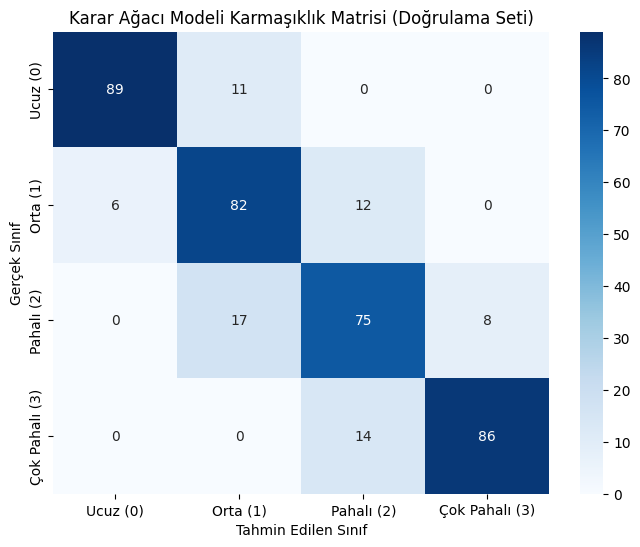

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_dt = confusion_matrix(y_val, dt_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'],
            yticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'])
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Karar Ağacı Modeli Karmaşıklık Matrisi (Doğrulama Seti)')
plt.show()

## Nihai Test Verisi Üzerinde Tahminler (test.csv)

In [46]:
final_test_predictions = best_rf_model.predict(X_test_final)

print("Nihai Test Verisi Üzerindeki Tahminler (İlk 10):")
print(final_test_predictions[:10])

import numpy as np
unique_predictions, counts = np.unique(final_test_predictions, return_counts=True)
print("\nNihai Tahminlerin Dağılımı:")
for pred, count in zip(unique_predictions, counts):
    print(f"Fiyat Aralığı {pred}: {count} adet")

Nihai Test Verisi Üzerindeki Tahminler (İlk 10):
[3 3 2 3 1 3 3 1 3 0]

Nihai Tahminlerin Dağılımı:
Fiyat Aralığı 0: 261 adet
Fiyat Aralığı 1: 250 adet
Fiyat Aralığı 2: 234 adet
Fiyat Aralığı 3: 255 adet


## Sonuç

Bu not defterinde, telefon fiyat segmenti sınıflandırma problemi için Karar Ağaçları ve Random Forest modellerini kullandık. Veri setini eğitim, doğrulama ve nihai test setlerine ayırarak modellerimizi eğittik ve performanslarını değerlendirdik.

`GridSearchCV` kullanarak Random Forest modelinin hiperparametrelerini optimize ettik ve en iyi performansı veren modeli belirledik. Optimize edilmiş Random Forest modeli, doğrulama seti üzerinde yüksek bir doğruluk oranı sergiledi ve karmaşıklık matrisi ile sınıflandırma performansı detaylı bir şekilde incelendi.

Son olarak, modelimizi gerçek ve daha önce hiç görülmemiş `test.csv` verisi üzerinde tahminler yapmak için kullandık. Bu analiz, farklı telefon özelliklerine dayanarak telefonların fiyat segmentlerini doğru bir şekilde tahmin etme yeteneğimizi göstermektedir. Bu not defteri, uçtan uca bir makine öğrenimi projesinin veri hazırlığı, model seçimi, eğitimi, optimizasyonu ve değerlendirme adımlarını kapsamaktadır.

In [47]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_val)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

print("==================================================================")
print("🌲 MODEL 1: DECISION TREE - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)")
print("==================================================================")
print(classification_report(y_val, dt_preds, target_names=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)']))

print("\n==================================================================")
print("🦁 MODEL 2: RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)")
print("==================================================================")
print(classification_report(y_val, rf_preds, target_names=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)']))

🌲 MODEL 1: DECISION TREE - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)
                precision    recall  f1-score   support

      Ucuz (0)       0.94      0.89      0.91       100
      Orta (1)       0.75      0.82      0.78       100
    Pahalı (2)       0.74      0.75      0.75       100
Çok Pahalı (3)       0.91      0.86      0.89       100

      accuracy                           0.83       400
     macro avg       0.83      0.83      0.83       400
  weighted avg       0.83      0.83      0.83       400


🦁 MODEL 2: RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)
                precision    recall  f1-score   support

      Ucuz (0)       0.94      0.96      0.95       100
      Orta (1)       0.82      0.82      0.82       100
    Pahalı (2)       0.82      0.79      0.81       100
Çok Pahalı (3)       0.93      0.95      0.94       100

      accuracy                           0.88       400
     macro avg       0.88      0.88      0.88       400
  weig

In [ ]:
df_importance.tail()

,Özellik,Önem Derecesi
11,px_height,0.052938
8,mobile_wt,0.032579
6,int_memory,0.031742
16,talk_time,0.023731
10,pc,0.022395


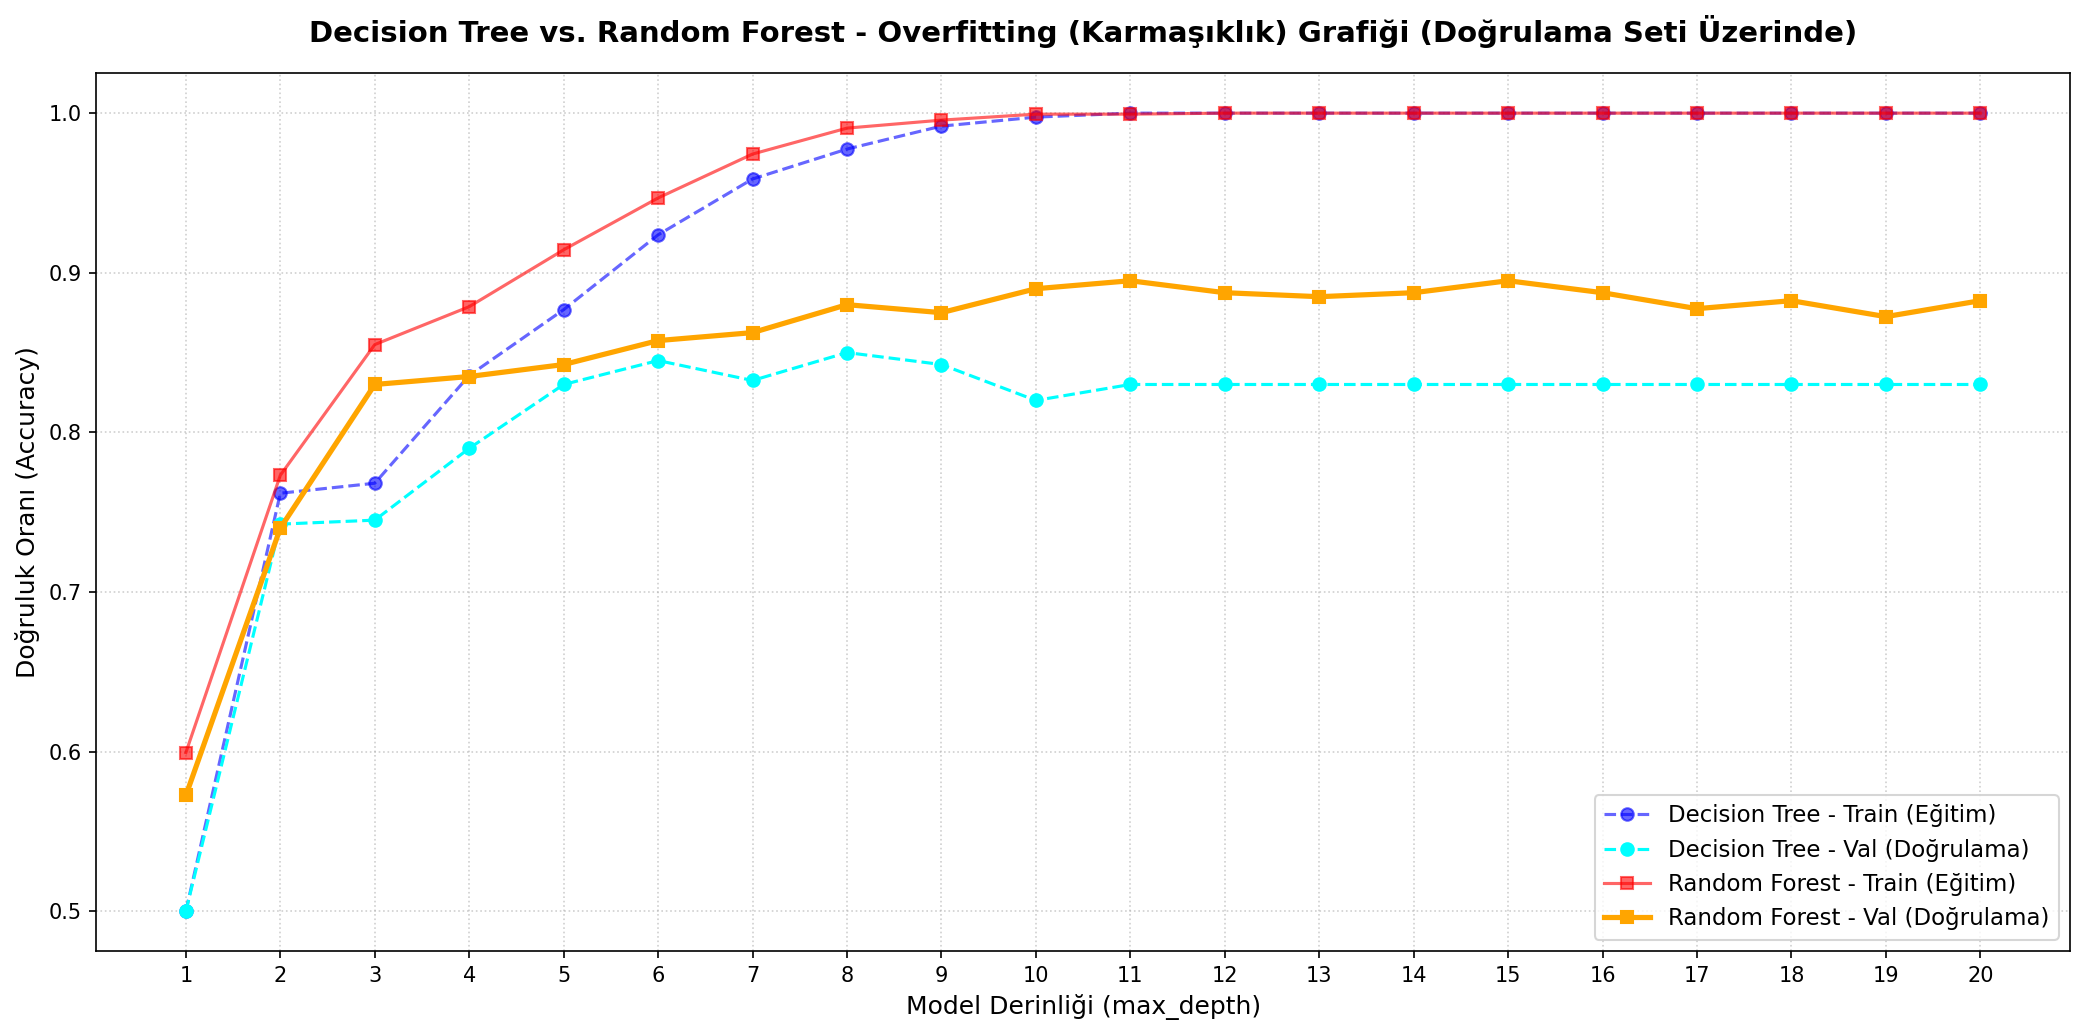

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

depths = range(1, 21)
dt_train_acc = []
dt_val_acc = []
rf_train_acc = []
rf_val_acc = []

for depth in depths:
    dt_model_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_model_temp.fit(X_train, y_train)
    dt_train_acc.append(accuracy_score(y_train, dt_model_temp.predict(X_train)))
    dt_val_acc.append(accuracy_score(y_val, dt_model_temp.predict(X_val)))

    rf_model_temp = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf_model_temp.fit(X_train, y_train)
    rf_train_acc.append(accuracy_score(y_train, rf_model_temp.predict(X_train)))
    rf_val_acc.append(accuracy_score(y_val, rf_model_temp.predict(X_val)))

plt.figure(figsize=(14, 7), dpi=150)

plt.plot(depths, dt_train_acc, '--o', label='Decision Tree - Train (Eğitim)', color='blue', alpha=0.6)
plt.plot(depths, dt_val_acc, '--o', label='Decision Tree - Val (Doğrulama)', color='cyan')

plt.plot(depths, rf_train_acc, '-s', label='Random Forest - Train (Eğitim)', color='red', alpha=0.6)
plt.plot(depths, rf_val_acc, '-s', label='Random Forest - Val (Doğrulama)', color='orange', linewidth=2.5)

plt.title('Decision Tree vs. Random Forest - Overfitting (Karmaşıklık) Grafiği (Doğrulama Seti Üzerinde)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Derinliği (max_depth)', fontsize=12)
plt.ylabel('Doğruluk Oranı (Accuracy)', fontsize=12)
plt.xticks(list(depths))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

In [49]:
from sklearn.model_selection import cross_val_score

print("🔄 --- 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA) SONUÇLARI ---")
print("-" * 60)

dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"🌲 Decision Tree 5 Tur Skorları : {dt_cv_scores}")
print(f"🌲 Decision Tree ORTALAMA Başarı: %{dt_cv_scores.mean()*100:.2f}")
print("-" * 60)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"🦁 Random Forest 5 Tur Skorları : {rf_cv_scores}")
print(f"🦁 Random Forest ORTALAMA Başarı: %{rf_cv_scores.mean()*100:.2f}")

🔄 --- 5-FOLD CROSS VALIDATION (ÇAPRAZ DOĞRULAMA) SONUÇLARI ---
------------------------------------------------------------
🌲 Decision Tree 5 Tur Skorları : [0.815625 0.815625 0.81875  0.784375 0.815625]
🌲 Decision Tree ORTALAMA Başarı: %81.00
------------------------------------------------------------
🦁 Random Forest 5 Tur Skorları : [0.86875  0.871875 0.86875  0.83125  0.846875]
🦁 Random Forest ORTALAMA Başarı: %85.75


## Random Forest Hiperparametre Optimizasyonu (n_estimators ve max_depth)

`GridSearchCV` kullanarak `n_estimators` ve `max_depth` için en iyi kombinasyonu bulalım.

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 8, 10, 12, None]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("En iyi parametreler:", grid_search.best_params_)
print("En iyi doğruluk skoru:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
En iyi parametreler: {'max_depth': 8, 'n_estimators': 200}
En iyi doğruluk skoru: 0.8706250000000001


### En iyi parametrelerle yeniden eğitilen modelin performans raporu

In [51]:
best_rf_model = grid_search.best_estimator_
best_rf_preds = best_rf_model.predict(X_val)

print("==================================================================")
print("🦁 OPTİMİZE EDİLMİŞ RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)")
print("==================================================================")
print(classification_report(y_val, best_rf_preds, target_names=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)']))

🦁 OPTİMİZE EDİLMİŞ RANDOM FOREST - TELEFON FİYAT SEGMENTİ RAPORU (Doğrulama Seti)
                precision    recall  f1-score   support

      Ucuz (0)       0.92      0.96      0.94       100
      Orta (1)       0.80      0.79      0.79       100
    Pahalı (2)       0.82      0.79      0.81       100
Çok Pahalı (3)       0.95      0.96      0.96       100

      accuracy                           0.88       400
     macro avg       0.87      0.88      0.87       400
  weighted avg       0.87      0.88      0.87       400



### Optimize Edilmiş Random Forest Modeli İçin Karmaşıklık Matrisi (Confusion Matrix)

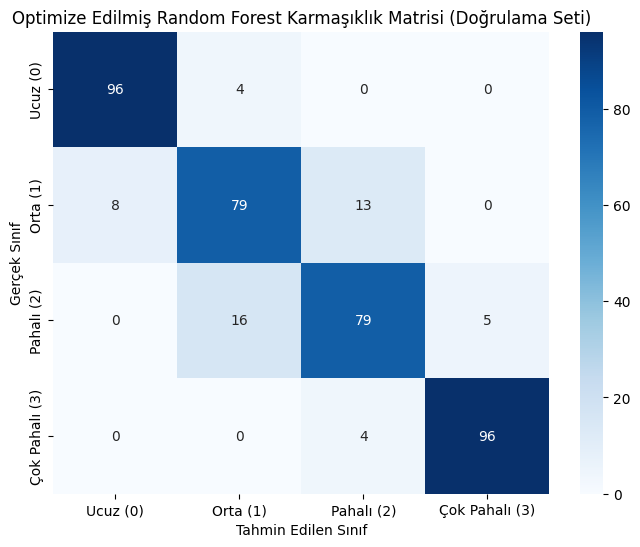

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, best_rf_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'],
            yticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'])
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Optimize Edilmiş Random Forest Karmaşıklık Matrisi (Doğrulama Seti)')
plt.show()

### Karar Ağacı Modeli İçin Karmaşıklık Matrisi (Confusion Matrix)

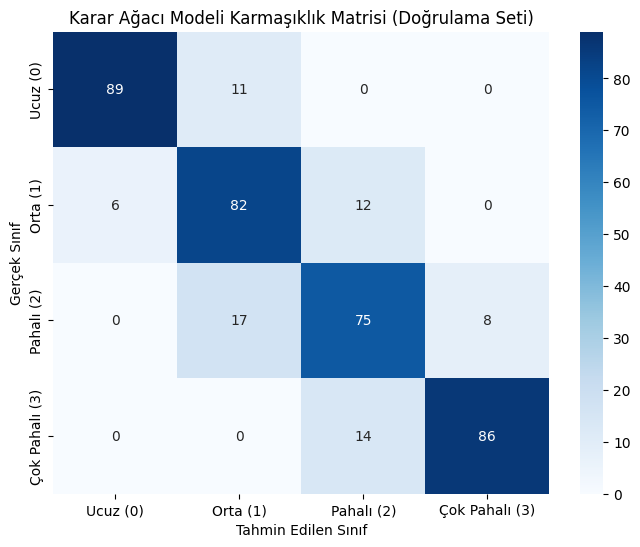

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_dt = confusion_matrix(y_val, dt_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'],
            yticklabels=['Ucuz (0)', 'Orta (1)', 'Pahalı (2)', 'Çok Pahalı (3)'])
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Karar Ağacı Modeli Karmaşıklık Matrisi (Doğrulama Seti)')
plt.show()